# Semantic equivalence across ALL 19 representations of every ETP equation

This notebook runs the full comparison pipeline on **every representation**
in `data/equations_representations_v2.json`, and then adds the setup that
actually reaches high accuracy.

| Family | Representations |
|---|---|
| **Formal** (5) | `lean`, `latex`, `tptp`, `smtlib`, `formal` |
| **Code** (3) | `py_lambda`, `py_cayley_table`, `ssa` |
| **Structural** (6) | `rpn`, `polish`, `slots`, `json_ast`, `ascii_tree`, `graphviz` |
| **Natural** (4) | `natural_language`, `word_problem`, `text`, `text2` |
| **Confusable** (1) | `confusable_vars` |

**Task.** For an ordered pair of equations (A, B), predict one of four
relations, using the dataset's convention from `data/decode_matrix.py`:

| label | meaning |
|---|---|
| `equivalent` | A ⇒ B and B ⇒ A |
| `stronger` | B ⇒ A only |
| `weaker` | A ⇒ B only |
| `incomparable` | neither |

**What this notebook does:**

1. **Sections 1–11: the embedding pipeline, run on all 19 views.** This is
   the original Natural Latents pipeline, fixed so that every view is
   actually used (the earlier version listed 19 but embedded only 5). It
   compares 5 against 19 views, ranks families and views, and keeps the
   symmetric baselines as the direction-blindness control.
2. **Section 12: advanced metrics, made runnable.** The earlier version had
   markdown pasted into a code cell, and an O(N²) Sinkhorn loop that could
   not finish on 19 views.
3. **Section 13: the semantic view.** `py_lambda` and `py_cayley_table` are
   *executable*, so the meaning of an equation can be measured directly by
   checking it against a bank of finite magmas. A counter-model that
   satisfies A but not B is a proof that A ⇏ B. This is where accuracy
   jumps to about 99%.
4. **Section 14: full scale.** The zero-training rule is checked on all
   ~11M resolvable pairs of the complete ETP relationship matrix.
5. **Sections 15–16: summary, confusion matrices, and the recommended
   setup** for further accuracy gains.

Every learned model is evaluated with the same discipline as before:
**node-held-out splits** (test equations are never seen in training, in any
pairing), and 5 independent seeds reported as mean ± std.

## 0. Setup

In [1]:
import sys, os, json, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             confusion_matrix, precision_recall_fscore_support)

sys.path.insert(0, '../src')
sys.path.insert(0, '../data')
from embeddings import make_generic_embedder
from embeddings_enhanced import (make_enhanced_domain_embedder, get_all_representations,
                                 REPRESENTATION_FAMILIES, REP_TO_FAMILY)
from resampling import NaturalLatentResampler
from losses import LOSS_FUNCTIONS
import magma_fingerprints as mf

warnings.filterwarnings('ignore', message="The parameter 'token_pattern' will not be used")
DATA_DIR = '../data'
OUT_DIR = '../outputs'
os.makedirs(OUT_DIR, exist_ok=True)

# ---- run configuration -----------------------------------------------------
SAMPLE_SIZE = 1200               # equations sampled for the learned-model experiments
PAIR_SAMPLE_SIZE = 15000         # ordered pairs (7,500 unordered x both directions)
USE_PREGENERATED_PAIRS = False   # True -> filter data/pairs_200k.csv (only ~3k pairs survive at 1,200 equations)
N_COMPONENTS = 8                 # SVD latent size per view
MAX_FEATURES = 500               # TF-IDF vocabulary cap per view
EXHAUSTIVE_SIZE3_MAGMAS = True   # add all 19,683 size-3 magmas to the semantic bank (+~30s at 1,200 equations)
RUN_FULL_SCALE_SEMANTIC = True   # Section 14: check the rule on all ~11M resolvable pairs (~3-4 min)

np.random.seed(42)
random.seed(42)
print("Setup complete.")

Setup complete.


## 1. Load all 19 representations

82 equations have no `natural_language` text, because its generation failed.
Every other representation is complete for all 4,694 equations. Keeping only
equations that have **all 19** representations leaves 4,612, so no view ever
sees missing text. That matters because TF-IDF would crash on `None`.

In [2]:
with open(os.path.join(DATA_DIR, 'equations_representations_v2.json')) as f:
    raw_equations = json.load(f)

ALL_VIEWS = get_all_representations()          # the 19 representation names
assert len(ALL_VIEWS) == 19
ORIGINAL_5_VIEWS = ['lean', 'latex', 'py_lambda', 'py_cayley_table', 'natural_language']

coverage = {v: sum(1 for e in raw_equations if e.get(v) not in (None, '')) for v in ALL_VIEWS}
print("Coverage per representation (of %d equations):" % len(raw_equations))
print(pd.Series(coverage).to_string())

all_equations = [e for e in raw_equations if all(e.get(v) not in (None, '') for v in ALL_VIEWS)]
print(f"\nEquations with ALL 19 representations: {len(all_equations)}")

random.seed(42)
sample_equations = random.sample(all_equations, SAMPLE_SIZE)   # random, not "first N"
sample_nodes_list = [e['node'] for e in sample_equations]
sample_nodes = set(sample_nodes_list)
print(f"Using a RANDOM sample of {len(sample_equations)} equations")

print("\n--- VIEW ON THE DATA: one real equation, ALL 19 representations, grouped by family ---")
example = sample_equations[10]
print(f"node = {example['node']}")
for fam, views in REPRESENTATION_FAMILIES.items():
    print(f"\n[{fam}]")
    for v in views:
        print(f"  {v:18s}: {str(example[v]).replace(chr(10), ' | ')[:110]}")

Coverage per representation (of 4694 equations):
lean                4694
latex               4694
py_lambda           4694
py_cayley_table     4694
natural_language    4612
formal              4694
ssa                 4694
rpn                 4694
polish              4694
slots               4694
json_ast            4694
ascii_tree          4694
graphviz            4694
tptp                4694
smtlib              4694
text                4694
text2               4694
word_problem        4694
confusable_vars     4694

Equations with ALL 19 representations: 4612
Using a RANDOM sample of 1200 equations

--- VIEW ON THE DATA: one real equation, ALL 19 representations, grouped by family ---
node = 265

[formal]
  lean              : example (G : Type u) [Magma G] : Prop := ∀ x y z : G, x = ((x ◇ y) ◇ y) ◇ z
  latex             : x = ((x \diamond y) \diamond y) \diamond z
  tptp              : fof(law, axiom, ![X,Y,Z] : X = op(op(op(X,Y),Y),Z)).
  smtlib            : (declare-sort M 0) | (

## 2. Labelled pairs

In [3]:
if USE_PREGENERATED_PAIRS:
    print("Loading pre-generated pairs from pairs_200k.csv...")
    pairs_raw = pd.read_csv(os.path.join(DATA_DIR, 'pairs_200k.csv'))
    pairs = pairs_raw[pairs_raw['node_a'].isin(sample_nodes) &
                      pairs_raw['node_b'].isin(sample_nodes) &
                      (pairs_raw['node_a'] != pairs_raw['node_b']) &
                      pairs_raw['relation'].isin(['equivalent', 'stronger', 'weaker', 'incomparable'])].copy()
    if len(pairs) > PAIR_SAMPLE_SIZE:
        pairs = pairs.sample(n=PAIR_SAMPLE_SIZE, random_state=42)
    pairs = pairs.reset_index(drop=True)
else:
    # Generate pairs directly from the sampled equations via the exact relationship
    # matrix; both directions of every unordered pair are included.
    print("Generating pairs from the relationship matrix...")
    from decode_matrix import load_matrix, relation_for
    matrix, meta = load_matrix()
    unordered_rows = []
    for i, a in enumerate(sample_nodes_list):
        for b in sample_nodes_list[i + 1:]:
            rel_ab = relation_for(matrix, a, b)
            rel_ba = relation_for(matrix, b, a)
            if rel_ab != 'unresolved' and rel_ba != 'unresolved':
                unordered_rows.append((a, b, rel_ab, rel_ba))
    print(f"Unordered pairs available (both directions resolved): {len(unordered_rows):,}")
    rng = random.Random(42)
    sampled_unordered = rng.sample(unordered_rows, min(PAIR_SAMPLE_SIZE // 2, len(unordered_rows)))
    rows = []
    for a, b, rel_ab, rel_ba in sampled_unordered:
        rows.append({'node_a': a, 'node_b': b, 'relation': rel_ab})
        rows.append({'node_a': b, 'node_b': a, 'relation': rel_ba})
    pairs = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Using {len(pairs):,} ordered pairs")
print(pairs['relation'].value_counts())
print("\n--- VIEW ON THE DATA: first 5 labelled pairs ---")
print(pairs.head())

Generating pairs from the relationship matrix...


Unordered pairs available (both directions resolved): 719,396
Using 15,000 ordered pairs
relation
incomparable    5762
weaker          3815
stronger        3815
equivalent      1608
Name: count, dtype: int64

--- VIEW ON THE DATA: first 5 labelled pairs ---
   node_a  node_b      relation
0    2560    2335        weaker
1    3031    1384        weaker
2    4155     435  incomparable
3    2890    3443  incomparable
4    4473    1852  incomparable


## 3. Embed all 19 views with two schemes

* **Generic:** character 2–4-gram TF-IDF, the same for every view (the
  original baseline scheme).
* **Family-specific** (`src/embeddings_enhanced.py`): each view gets the
  tokenizer of its family (formal / code / structural / natural /
  confusable), and char n-grams are concatenated with word n-grams.

The old `make_domain_specific_embedder` only had tokenizers for the original
5 views, and silently fell back to a word tokenizer for the other 14. For
example, it drops `◇` and `=` from `rpn`/`polish`, which are *all* of their
content. So the family-specific scheme is the right domain-specific
embedder for 19 views.

In [4]:
representations = {v: {e['node']: e[v] for e in sample_equations} for v in ALL_VIEWS}

embed_generic = make_generic_embedder(char_ngrams=(2, 4), max_features=MAX_FEATURES)
_enhanced = make_enhanced_domain_embedder(char_ngrams=(2, 4), word_ngrams=(1, 2), max_features=MAX_FEATURES)
def embed_family(texts, fit_key=None):
    # adapter: NaturalLatentResampler calls embed_fn(texts, fit_key=view_name)
    return _enhanced.fit_transform(texts, fit_key)

t0 = time.time()
resampler_generic = NaturalLatentResampler(embed_generic, ridge_alpha=1.0, n_components=N_COMPONENTS)
resampler_generic.fit_embeddings(representations)
resampler_family = NaturalLatentResampler(embed_family, ridge_alpha=1.0, n_components=N_COMPONENTS)
resampler_family.fit_embeddings(representations)
print(f"Embedded 19 views x 2 schemes in {time.time()-t0:.1f}s\n")

print(f"{'view':18s} {'family':11s} {'generic':>12s} {'family-specific':>16s}")
for v in ALL_VIEWS:
    print(f"{v:18s} {REP_TO_FAMILY[v]:11s} {str(resampler_generic.view_matrices[v].shape):>12s} "
          f"{str(resampler_family.view_matrices[v].shape):>16s}")

Embedded 19 views x 2 schemes in 6.1s

view               family           generic  family-specific
lean               formal       (1200, 361)      (1200, 335)
latex              formal       (1200, 220)      (1200, 265)
py_lambda          code         (1200, 284)      (1200, 304)
py_cayley_table    code         (1200, 393)      (1200, 324)
natural_language   natural      (1200, 500)      (1200, 500)
formal             formal       (1200, 199)      (1200, 244)
ssa                code         (1200, 240)      (1200, 346)
rpn                structural   (1200, 141)      (1200, 189)
polish             structural   (1200, 123)      (1200, 169)
slots              structural   (1200, 177)      (1200, 212)
json_ast           structural   (1200, 145)      (1200, 186)
ascii_tree         structural   (1200, 143)      (1200, 182)
graphviz           structural   (1200, 402)      (1200, 389)
tptp               formal       (1200, 392)      (1200, 315)
smtlib             formal       (1200, 437)   

## 4. Cross-view correlation, 19 × 19

This checks whether each view's pairwise-distance structure agrees with
every other view's. Views are ordered by family, so blocks along the
diagonal show within-family agreement.

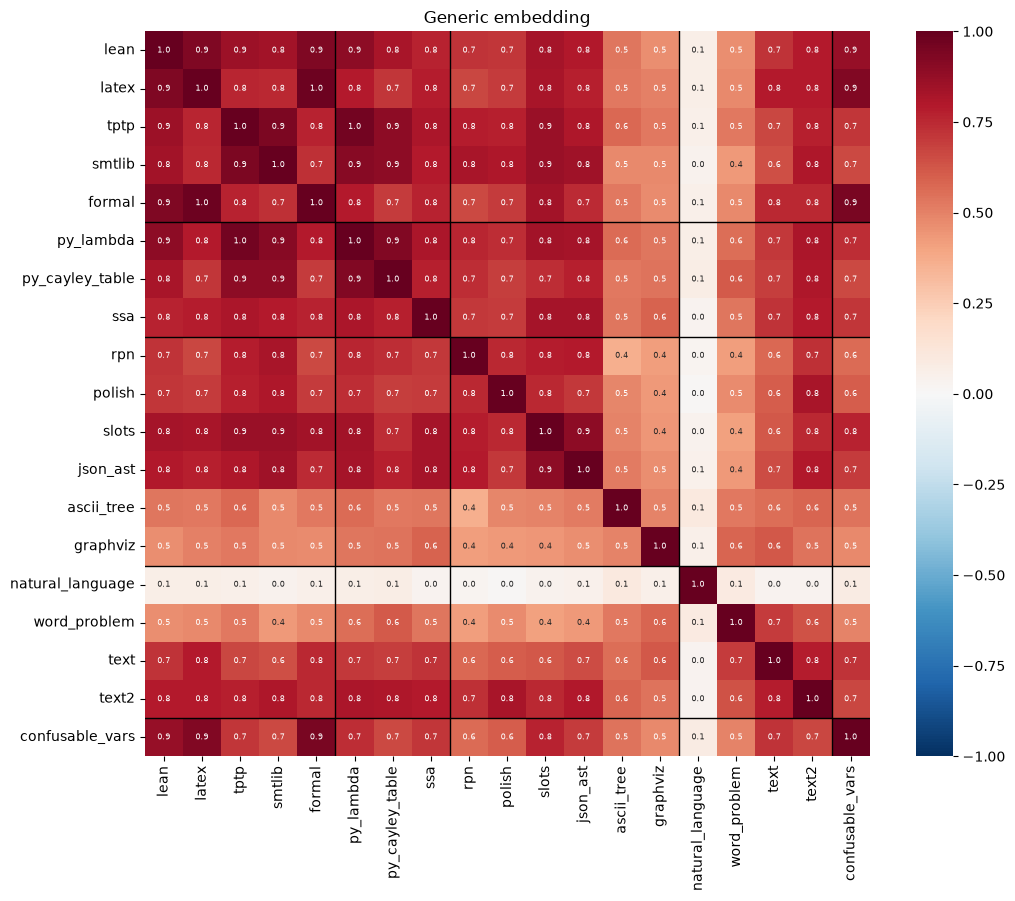

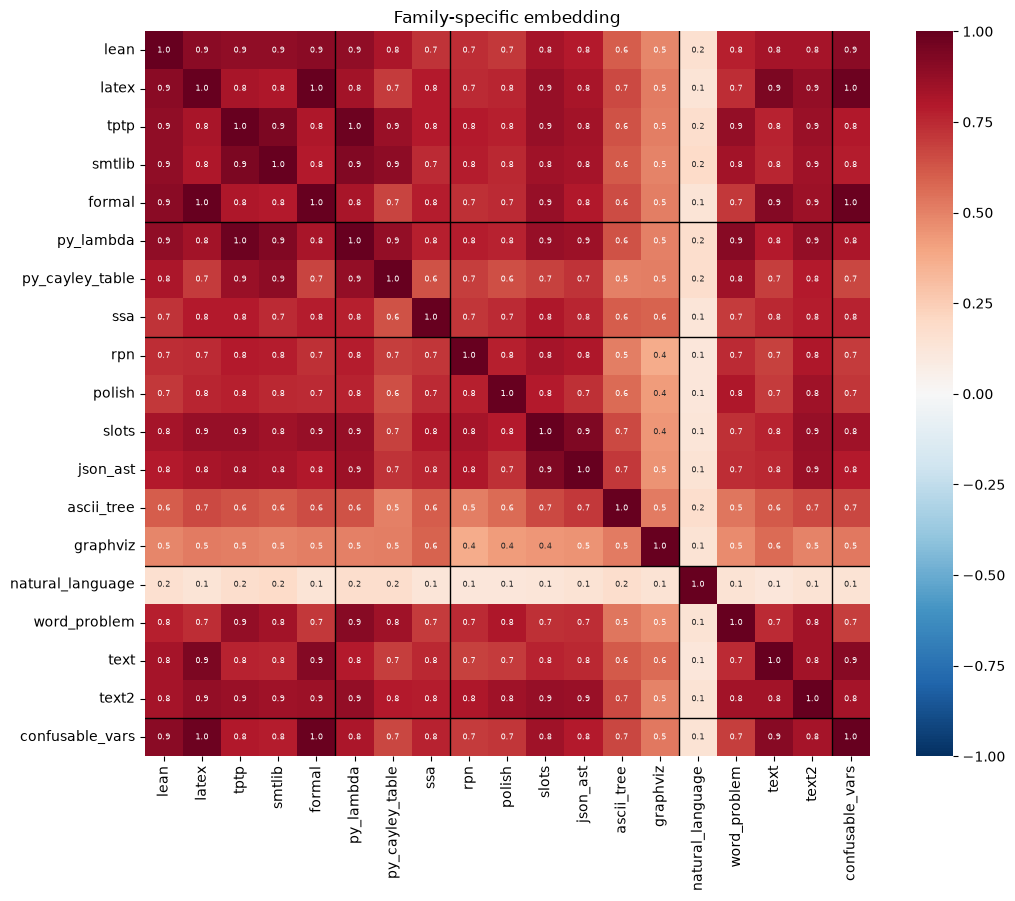

generic          mean within-family corr = 0.650   mean across-family corr = 0.620
family-specific  mean within-family corr = 0.689   mean across-family corr = 0.688


In [5]:
from scipy.spatial.distance import pdist

FAMILY_ORDER = [v for fam in REPRESENTATION_FAMILIES.values() for v in fam]

def view_correlation_heatmap(view_matrices, title):
    views = FAMILY_ORDER
    profiles = {v: pdist(view_matrices[v]) for v in views}
    corr = np.array([[np.corrcoef(profiles[a], profiles[b])[0, 1] for b in views] for a in views])
    plt.figure(figsize=(11, 9))
    sns.heatmap(corr, xticklabels=views, yticklabels=views, annot=True, fmt='.1f',
                annot_kws={'size': 6}, cmap='RdBu_r', vmin=-1, vmax=1, square=True)
    # family boundaries
    edges = np.cumsum([len(v) for v in REPRESENTATION_FAMILIES.values()])[:-1]
    for e in edges:
        plt.axhline(e, color='k', lw=1); plt.axvline(e, color='k', lw=1)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'correlation_heatmap_19views_{title.replace(" ", "_")}.png'), dpi=100)
    plt.show()
    return views, corr

views_g, corr_generic = view_correlation_heatmap(resampler_generic.view_matrices, "Generic embedding")
views_f, corr_family = view_correlation_heatmap(resampler_family.view_matrices, "Family-specific embedding")

fam_of = np.array([REP_TO_FAMILY[v] for v in FAMILY_ORDER])
for name, corr in [('generic', corr_generic), ('family-specific', corr_family)]:
    same = (fam_of[:, None] == fam_of[None, :]) & ~np.eye(len(fam_of), dtype=bool)
    print(f"{name:16s} mean within-family corr = {corr[same].mean():.3f}   "
          f"mean across-family corr = {corr[~same & ~np.eye(len(fam_of), dtype=bool)].mean():.3f}")

## 5. Per-view latents, raw and resampled, for both schemes

This gives four latent sets: {generic, family-specific} × {raw, resampled}.
Resampling is the Natural Latents purification step: each view is
reconstructed from the other **18** views by cross-validated Ridge
regression, which keeps only the information the views share.

In [6]:
t0 = time.time()
latents_generic_raw = resampler_generic.raw_per_view_latents(n_components=N_COMPONENTS)
latents_generic_resampled = resampler_generic.per_view_resampled_latents(n_components=N_COMPONENTS)
print(f"  generic scheme done in {time.time()-t0:.1f}s")
t0 = time.time()
latents_family_raw = resampler_family.raw_per_view_latents(n_components=N_COMPONENTS)
latents_family_resampled = resampler_family.per_view_resampled_latents(n_components=N_COMPONENTS)
print(f"  family-specific scheme done in {time.time()-t0:.1f}s")

example_node = sample_equations[10]['node']
print("\n--- VIEW: one equation's resampled latent, rpn view, family-specific embedding ---")
print(np.round(latents_family_resampled['rpn'][example_node], 3))

  generic scheme done in 29.1s


  family-specific scheme done in 29.8s

--- VIEW: one equation's resampled latent, rpn view, family-specific embedding ---
[-0.192  0.348 -0.079 -0.324 -0.408 -0.254 -0.064  0.135]


## 6. Directional losses, independently per view

For each of 4 latent sets × 19 views × 5 losses, this computes an N × N
matrix: 380 matrices in total.

In [7]:
def compute_all_losses(latents_dict, node_order):
    '''latents_dict: view -> {node: vector}. Returns view -> loss_name -> NxN matrix.'''
    result = {}
    for view, node_latents in latents_dict.items():
        mat = np.stack([node_latents[n] for n in node_order])
        result[view] = {loss_name: fn(mat) for loss_name, fn in LOSS_FUNCTIONS.items()}
    return result

node_order = sorted(set(pairs.node_a) | set(pairs.node_b))
node_idx = {n: i for i, n in enumerate(node_order)}

LATENT_SETS = {
    'Generic, RAW': latents_generic_raw,
    'Generic, RESAMPLED': latents_generic_resampled,
    'Family-specific, RAW': latents_family_raw,
    'Family-specific, RESAMPLED': latents_family_resampled,
}
LOSSES = {}
for name, lat in LATENT_SETS.items():
    t0 = time.time()
    LOSSES[name] = compute_all_losses(lat, node_order)
    print(f"  {name:28s} 19 views x {len(LOSS_FUNCTIONS)} losses in {time.time()-t0:.1f}s")

i_ex, j_ex = node_idx[sample_equations[10]['node']], node_idx[sample_equations[20]['node']]
print("\n--- VIEW: KL divergence for one real pair, family-specific + resampled, in 3 different views ---")
for v in ['lean', 'rpn', 'word_problem']:
    L = LOSSES['Family-specific, RESAMPLED'][v]['KL']
    print(f"  {v:14s} KL(A|B) = {L[i_ex, j_ex]:8.3f}   KL(B|A) = {L[j_ex, i_ex]:8.3f}")

  Generic, RAW                 19 views x 5 losses in 11.8s


  Generic, RESAMPLED           19 views x 5 losses in 11.6s


  Family-specific, RAW         19 views x 5 losses in 11.5s


  Family-specific, RESAMPLED   19 views x 5 losses in 11.7s

--- VIEW: KL divergence for one real pair, family-specific + resampled, in 3 different views ---
  lean           KL(A|B) =   15.209   KL(B|A) =   32.007
  rpn            KL(A|B) =   29.843   KL(B|A) =   17.332
  word_problem   KL(A|B) =   30.238   KL(B|A) =   14.363


## 7. Labels, feature builders and the evaluation harness

Every feature builder is a function of the **ordered** index arrays
`(I, J)`. Calling it with `(J, I)` gives the features of the swapped pair,
which the swap-consistency option in Section 13 uses.

In [8]:
label_map = {'equivalent': 0, 'stronger': 1, 'weaker': 2, 'incomparable': 3}
LABELS = [0, 1, 2, 3]
NAMES = ['equivalent', 'stronger', 'weaker', 'incomparable']
SWAP = np.array([0, 2, 1, 3])   # label of (B, A) given label of (A, B)

ii = np.array([node_idx[a] for a in pairs.node_a])
jj = np.array([node_idx[b] for b in pairs.node_b])
y = np.array([label_map[r] for r in pairs.relation])

LOSS_NAMES = ['KL', 'CrossEntropy', 'RankInfoGain', 'SignedLLR', 'PMI_control']
MIX_LOSSES = ['KL', 'CrossEntropy', 'RankInfoGain', 'SignedLLR']

def loss_features(losses_dict, loss_names, views, I=None, J=None):
    '''Both directions of every (loss, view): 2 * len(loss_names) * len(views) columns.'''
    I = ii if I is None else I
    J = jj if J is None else J
    cols = []
    for ln in loss_names:
        for v in views:
            m = losses_dict[v][ln]
            cols += [m[I, J], m[J, I]]
    return np.stack(cols, axis=1)

print(f"Total pairs: {len(y)}")
print(f"Label distribution: {dict(zip(NAMES, np.bincount(y, minlength=4)))}")
print(f"Mix feature width: 5 views -> {loss_features(LOSSES['Generic, RAW'], MIX_LOSSES, ORIGINAL_5_VIEWS).shape[1]}, "
      f"19 views -> {loss_features(LOSSES['Generic, RAW'], MIX_LOSSES, ALL_VIEWS).shape[1]}")

Total pairs: 15000
Label distribution: {'equivalent': np.int64(1608), 'stronger': np.int64(3815), 'weaker': np.int64(3815), 'incomparable': np.int64(5762)}
Mix feature width: 5 views -> 40, 19 views -> 152


In [9]:
def node_holdout_split(node_order, ii, jj, test_frac=0.3, seed=42):
    '''Test equations are never seen in training, in any pairing.'''
    rng = np.random.RandomState(seed)
    perm = rng.permutation(len(node_order))
    is_test = np.zeros(len(node_order), dtype=bool)
    is_test[perm[:int(test_frac * len(node_order))]] = True
    train_mask = ~is_test[ii] & ~is_test[jj]
    test_mask = is_test[ii] & is_test[jj]
    return train_mask, test_mask

SPLIT_SEEDS = [42, 7, 123, 99, 256]
SPLITS = [node_holdout_split(node_order, ii, jj, seed=s) for s in SPLIT_SEEDS]
print(f"Example split (seed={SPLIT_SEEDS[0]}): train pairs {SPLITS[0][0].sum():,}   test pairs {SPLITS[0][1].sum():,}")

def make_model(kind):
    if kind == 'rf':      # the original configuration, unchanged
        return RandomForestClassifier(n_estimators=150, max_depth=8, min_samples_leaf=10,
                                      class_weight='balanced', random_state=42, n_jobs=-1)
    if kind == 'hgb':     # gradient boosting: better for heterogeneous / many features
        return HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                              class_weight='balanced', random_state=42)
    raise ValueError(kind)

def summarise(label, y_true_list, y_pred_list, extra=None):
    accs = [accuracy_score(t, p) for t, p in zip(y_true_list, y_pred_list)]
    bals = [balanced_accuracy_score(t, p) for t, p in zip(y_true_list, y_pred_list)]
    cm = sum(confusion_matrix(t, p, labels=LABELS) for t, p in zip(y_true_list, y_pred_list))
    prf = [precision_recall_fscore_support(t, p, labels=LABELS, zero_division=0) for t, p in zip(y_true_list, y_pred_list)]
    r = {'label': label,
         'accuracy': float(np.mean(accs)), 'accuracy_std': float(np.std(accs)),
         'balanced_accuracy': float(np.mean(bals)), 'balanced_accuracy_std': float(np.std(bals)),
         'confusion_matrix': cm,
         'precision': np.mean([x[0] for x in prf], axis=0), 'recall': np.mean([x[1] for x in prf], axis=0),
         'f1': np.mean([x[2] for x in prf], axis=0), 'n_splits': len(y_true_list)}
    r.update(extra or {})
    return r

def run_and_evaluate(X, label, model='rf', X_swapped=None, group=None):
    '''Fit on each node-holdout split, predict its test pairs.
    X_swapped (features of (B, A) for every row) turns on swap-consistency:
    training is augmented with swapped pairs and swapped labels, and the test
    prediction averages P(y | A, B) with the label-swapped P(y | B, A), so
    the two directions of a pair can never get contradictory answers.'''
    truths, preds = [], []
    for train_mask, test_mask in SPLITS:
        clf = make_model(model)
        if X_swapped is None:
            clf.fit(X[train_mask], y[train_mask])
            pred = clf.predict(X[test_mask])
        else:
            clf.fit(np.vstack([X[train_mask], X_swapped[train_mask]]),
                    np.concatenate([y[train_mask], SWAP[y[train_mask]]]))
            proba = clf.predict_proba(X[test_mask]) + clf.predict_proba(X_swapped[test_mask])[:, SWAP]
            pred = clf.classes_[proba.argmax(axis=1)]
        truths.append(y[test_mask]); preds.append(pred)
    return summarise(label, truths, preds, {'group': group, 'n_features': X.shape[1]})

results = []
def record(r):
    results.append(r)
    print(f"{r['label']:72s} acc={r['accuracy']:.3f}±{r['accuracy_std']:.3f}  "
          f"bal={r['balanced_accuracy']:.3f}±{r['balanced_accuracy_std']:.3f}  weaker_recall={r['recall'][2]:.3f}")

Example split (seed=42): train pairs 7,458   test pairs 1,280


## 8. Symmetric baselines: cosine, Euclidean, tree edit distance

These are the control. Because $f(A,B){=}f(B,A)$, the pair (A,B) and the
pair (B,A) get identical features, and therefore identical predictions.
The classifier-independent signature is that **the `stronger` row and the
`weaker` row of the confusion matrix are exactly equal**.

In [10]:
from symmetric_methods import SYMMETRIC_METHODS
SYMMETRIC_NAMES = ['Euclidean', 'CosineSimilarity']

SYM = {}
for name, lat in LATENT_SETS.items():
    SYM[name] = {}
    for v in ALL_VIEWS:
        mat = np.stack([lat[v][n] for n in node_order])
        SYM[name][v] = {m: SYMMETRIC_METHODS[m](mat) for m in SYMMETRIC_NAMES}

m = SYM['Generic, RESAMPLED']['lean']['CosineSimilarity']
print(f"cos(A,B) = {m[i_ex, j_ex]!r}\ncos(B,A) = {m[j_ex, i_ex]!r}")
print(f"Max |cos(A,B) - cos(B,A)| over the full {m.shape[0]}x{m.shape[0]} grid, all 19 views: "
      f"{max(np.abs(SYM['Generic, RESAMPLED'][v]['CosineSimilarity'] - SYM['Generic, RESAMPLED'][v]['CosineSimilarity'].T).max() for v in ALL_VIEWS):.1e}")

def symmetric_features(sym_dict, method, views):
    return np.stack([sym_dict[v][method][ii, jj] for v in views], axis=1)   # one column per view

from baseline_metrics import tree_edit_distance_equations
formal_by_node = {e['node']: e['formal'] for e in sample_equations}
t0 = time.time()
X_tree_edit = np.array([tree_edit_distance_equations(formal_by_node[node_order[i]], formal_by_node[node_order[j]])
                        for i, j in zip(ii, jj)]).reshape(-1, 1)
print(f"Tree edit similarity for {len(X_tree_edit):,} pairs in {time.time()-t0:.1f}s")

cos(A,B) = np.float64(0.7029089505561841)
cos(B,A) = np.float64(0.7029089505561841)
Max |cos(A,B) - cos(B,A)| over the full 1200x1200 grid, all 19 views: 0.0e+00


Tree edit similarity for 15,000 pairs in 26.3s


## 9. Main evaluation: every loss × latent set, 5 views vs all 19

The model is the original Random Forest configuration, unchanged, so these
numbers are directly comparable with the earlier 5-view notebook.

In [11]:
print(f"Directional losses: {len(LATENT_SETS)} latent sets x ({len(LOSS_NAMES)} single losses + Mix), all 19 views\n")
for combo, L in LOSSES.items():
    for ln in LOSS_NAMES:
        record(run_and_evaluate(loss_features(L, [ln], ALL_VIEWS), f"{combo} | 19 views | loss={ln}", group='embedding'))
    record(run_and_evaluate(loss_features(L, MIX_LOSSES, ALL_VIEWS), f"{combo} | 19 views | Mix(KL+CE+Rank+LLR)", group='embedding'))

print("\nSame Mix, restricted to the ORIGINAL 5 views (the direct 5-vs-19 comparison):\n")
for combo, L in LOSSES.items():
    record(run_and_evaluate(loss_features(L, MIX_LOSSES, ORIGINAL_5_VIEWS), f"{combo} | 5 original views | Mix(KL+CE+Rank+LLR)", group='embedding-5views'))

print("\nSymmetric baselines (all 19 views, one column per view):\n")
for combo, S in SYM.items():
    for method in SYMMETRIC_NAMES:
        record(run_and_evaluate(symmetric_features(S, method, ALL_VIEWS), f"{combo} | SYMMETRIC {method}", group='symmetric'))
record(run_and_evaluate(X_tree_edit, "Tree edit distance (formal view, SYMMETRIC)", group='symmetric'))

Directional losses: 4 latent sets x (5 single losses + Mix), all 19 views



Generic, RAW | 19 views | loss=KL                                        acc=0.438±0.031  bal=0.454±0.027  weaker_recall=0.415


Generic, RAW | 19 views | loss=CrossEntropy                              acc=0.442±0.036  bal=0.459±0.035  weaker_recall=0.423


Generic, RAW | 19 views | loss=RankInfoGain                              acc=0.395±0.018  bal=0.444±0.027  weaker_recall=0.407


Generic, RAW | 19 views | loss=SignedLLR                                 acc=0.432±0.031  bal=0.450±0.032  weaker_recall=0.381


...

Family-specific, RAW | SYMMETRIC Euclidean                               acc=0.396±0.034  bal=0.408±0.038  weaker_recall=0.198


Family-specific, RAW | SYMMETRIC CosineSimilarity                        acc=0.339±0.010  bal=0.353±0.013  weaker_recall=0.191


Family-specific, RESAMPLED | SYMMETRIC Euclidean                         acc=0.375±0.028  bal=0.389±0.036  weaker_recall=0.199


Family-specific, RESAMPLED | SYMMETRIC CosineSimilarity                  acc=0.331±0.015  bal=0.358±0.016  weaker_recall=0.179


Tree edit distance (formal view, SYMMETRIC)                              acc=0.272±0.020  bal=0.327±0.016  weaker_recall=0.298


## 10. Which representations carry the signal?

This uses the best latent set from Section 9. There are three views of the
question:

* **Per family:** the Mix features from only one family's views.
* **Leave-one-family-out:** all 19 views minus one family. A drop means that
  family added something the others did not.
* **Per view:** each single view on its own (8 Mix features).

Best latent set from Section 9: Generic, RAW



    family  n_views  only_this_family_bal_acc  all_but_this_family_bal_acc
   natural        4                     0.422                        0.448
structural        6                     0.415                        0.454
      code        3                     0.393                        0.462
    formal        5                     0.349                        0.467
confusable        1                     0.331                        0.469


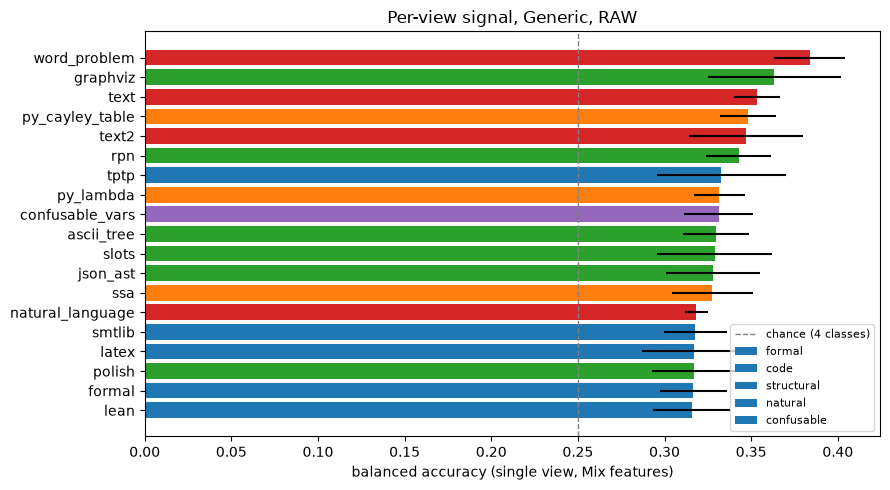

,view,family,balanced_accuracy,balanced_accuracy_std,accuracy
0,word_problem,natural,0.383750,0.020376,0.345038
1,graphviz,structural,0.363407,0.038469,0.316413
2,text,natural,0.353189,0.013173,0.297094
3,py_cayley_table,code,0.348169,0.016028,0.307320
4,text2,natural,0.347059,0.032790,0.355400
5,rpn,structural,0.342692,0.018736,0.329583
6,tptp,formal,0.332615,0.037266,0.298655
7,py_lambda,code,0.331657,0.014931,0.318807
8,confusable_vars,confusable,0.331204,0.019893,0.302808
9,ascii_tree,structural,0.329644,0.019038,0.284757


In [12]:
emb_results = [r for r in results if r.get('group') == 'embedding' and 'Mix' in r['label']]
BEST_COMBO = max(emb_results, key=lambda r: r['balanced_accuracy'])['label'].split(' | ')[0]
L_best = LOSSES[BEST_COMBO]
print(f"Best latent set from Section 9: {BEST_COMBO}\n")

family_rows = []
for fam, views in REPRESENTATION_FAMILIES.items():
    r_only = run_and_evaluate(loss_features(L_best, MIX_LOSSES, views), f"{BEST_COMBO} | family={fam} only", group='family')
    rest = [v for v in ALL_VIEWS if v not in views]
    r_wo = run_and_evaluate(loss_features(L_best, MIX_LOSSES, rest), f"{BEST_COMBO} | all but family={fam}", group='family')
    family_rows.append({'family': fam, 'n_views': len(views),
                        'only_this_family_bal_acc': r_only['balanced_accuracy'],
                        'all_but_this_family_bal_acc': r_wo['balanced_accuracy']})
family_df = pd.DataFrame(family_rows).sort_values('only_this_family_bal_acc', ascending=False)
print(family_df.to_string(index=False, float_format='%.3f'))

view_rows = []
for v in ALL_VIEWS:
    r = run_and_evaluate(loss_features(L_best, MIX_LOSSES, [v]), f"{BEST_COMBO} | single view={v}", group='view')
    view_rows.append({'view': v, 'family': REP_TO_FAMILY[v], 'balanced_accuracy': r['balanced_accuracy'],
                      'balanced_accuracy_std': r['balanced_accuracy_std'], 'accuracy': r['accuracy']})
view_df = pd.DataFrame(view_rows).sort_values('balanced_accuracy', ascending=False).reset_index(drop=True)

plt.figure(figsize=(9, 5))
palette = dict(zip(REPRESENTATION_FAMILIES, sns.color_palette('tab10', len(REPRESENTATION_FAMILIES))))
plt.barh(view_df['view'][::-1], view_df['balanced_accuracy'][::-1],
         xerr=view_df['balanced_accuracy_std'][::-1], color=[palette[f] for f in view_df['family'][::-1]])
plt.axvline(0.25, ls='--', color='grey', lw=1, label='chance (4 classes)')
for fam, c in palette.items():
    plt.barh([], [], color=c, label=fam)
plt.xlabel('balanced accuracy (single view, Mix features)'); plt.legend(loc='lower right', fontsize=8)
plt.title(f'Per-view signal, {BEST_COMBO}'); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'per_view_balanced_accuracy.png'), dpi=100); plt.show()
view_df

## 11. Mix + cosine similarity in one Random Forest

Cosine carries no direction, but it can still help separate `equivalent`
from `incomparable`.

In [13]:
for combo in LOSSES:
    X = np.concatenate([loss_features(LOSSES[combo], MIX_LOSSES, ALL_VIEWS),
                        symmetric_features(SYM[combo], 'CosineSimilarity', ALL_VIEWS)], axis=1)
    record(run_and_evaluate(X, f"{combo} | 19 views | Mix + Cosine (COMBINED)", group='embedding'))

Generic, RAW | 19 views | Mix + Cosine (COMBINED)                        acc=0.459±0.026  bal=0.480±0.027  weaker_recall=0.443


Generic, RESAMPLED | 19 views | Mix + Cosine (COMBINED)                  acc=0.443±0.022  bal=0.471±0.023  weaker_recall=0.411


Family-specific, RAW | 19 views | Mix + Cosine (COMBINED)                acc=0.432±0.034  bal=0.470±0.035  weaker_recall=0.424


Family-specific, RESAMPLED | 19 views | Mix + Cosine (COMBINED)          acc=0.425±0.026  bal=0.462±0.034  weaker_recall=0.391


## 12. Advanced metrics (fixed, and fast enough for 19 views)

These are the metrics the earlier version pasted in as markdown, now real
code with three corrections:

* **Wasserstein.** `earth_movers_directional` ran about 1.4M Python-level
  Sinkhorn calls per view. It is also *not* directional: entropic OT with a
  symmetric cost matrix is symmetric, so any asymmetry was solver noise.
  This version uses the exact 1-D Wasserstein-1 distance (the L1 distance
  between CDFs), vectorised, and only on the pairs actually used.
* **Compression (NCD, compression gain).** These are computed on the pairs
  used, not the full N×N grid.
* **Algebraic properties.** The subsumption score in `advanced_metrics.py`
  is symmetric (it counts equal properties), so this version feeds the
  *ordered* property vectors [p(A), p(B), p(A)−p(B)] instead.

In [14]:
from advanced_metrics import extract_algebraic_properties, algebraic_property_vector, edit_script_feature_matrix, tree_kernel_matrix
import zlib

def wasserstein_1d_pairs(latent_mat, I, J):
    '''Exact W1 between |latent| profiles treated as distributions on the grid 0..d-1.'''
    P = np.abs(latent_mat) + 1e-8
    P = P / P.sum(axis=1, keepdims=True)
    cdf = np.cumsum(P, axis=1)
    return np.abs(cdf[I] - cdf[J]).sum(axis=1)

lat_best = LATENT_SETS[BEST_COMBO]
X_wasser = np.stack([wasserstein_1d_pairs(np.stack([lat_best[v][n] for n in node_order]), ii, jj)
                     for v in ALL_VIEWS], axis=1)

formal_texts = [formal_by_node[n] for n in node_order]
csize = np.array([len(zlib.compress(t.encode(), 9)) for t in formal_texts])
c_ab = np.array([len(zlib.compress((formal_texts[i] + formal_texts[j]).encode(), 9)) for i, j in zip(ii, jj)])
c_ba = np.array([len(zlib.compress((formal_texts[j] + formal_texts[i]).encode(), 9)) for i, j in zip(ii, jj)])
ncd = (np.minimum(c_ab, c_ba) - np.minimum(csize[ii], csize[jj])) / np.maximum(csize[ii], csize[jj])
gain_ab = (csize[jj] - (c_ab - csize[ii])) / csize[jj]      # does A help compress B?
gain_ba = (csize[ii] - (c_ba - csize[jj])) / csize[ii]
X_compression = np.stack([ncd, gain_ab, gain_ba], axis=1)

P_alg = np.stack([algebraic_property_vector(extract_algebraic_properties(t)) for t in formal_texts])
X_alg = np.concatenate([P_alg[ii], P_alg[jj], P_alg[ii] - P_alg[jj]], axis=1)

t0 = time.time()
X_edit = edit_script_feature_matrix(formal_by_node, node_order, ii, jj)
X_tree_kernel = tree_kernel_matrix(formal_by_node, node_order)[ii, jj].reshape(-1, 1)
print(f"Advanced features built ({time.time()-t0:.1f}s for edit + tree kernel)")

record(run_and_evaluate(X_wasser, f"{BEST_COMBO} | Wasserstein-1D (19 views, symmetric)", group='advanced'))
record(run_and_evaluate(X_compression, "Compression: NCD + directional gain (formal view)", group='advanced'))
record(run_and_evaluate(X_alg, "Algebraic property vectors [p(A), p(B), p(A)-p(B)]", group='advanced'))
record(run_and_evaluate(X_edit, "Edit script features (formal view)", group='advanced'))
record(run_and_evaluate(X_tree_kernel, "Tree convolution kernel (SYMMETRIC)", group='advanced'))

X_best_mix = loss_features(L_best, MIX_LOSSES, ALL_VIEWS)
X_super_emb = np.concatenate([X_best_mix, X_wasser, X_compression, X_alg, X_edit], axis=1)
record(run_and_evaluate(X_super_emb, f"Embedding super-model: Mix(19) + Wasserstein + compression + algebraic + edit", group='advanced'))
record(run_and_evaluate(X_super_emb, f"Embedding super-model, gradient boosting", model='hgb', group='advanced'))

Advanced features built (2.7s for edit + tree kernel)


Generic, RAW | Wasserstein-1D (19 views, symmetric)                      acc=0.321±0.030  bal=0.312±0.027  weaker_recall=0.166


Compression: NCD + directional gain (formal view)                        acc=0.348±0.016  bal=0.354±0.015  weaker_recall=0.313


Algebraic property vectors [p(A), p(B), p(A)-p(B)]                       acc=0.625±0.029  bal=0.652±0.032  weaker_recall=0.631


Edit script features (formal view)                                       acc=0.520±0.024  bal=0.585±0.015  weaker_recall=0.585


Tree convolution kernel (SYMMETRIC)                                      acc=0.271±0.015  bal=0.348±0.011  weaker_recall=0.020


Embedding super-model: Mix(19) + Wasserstein + compression + algebraic + edit acc=0.580±0.035  bal=0.628±0.030  weaker_recall=0.599


Embedding super-model, gradient boosting                                 acc=0.712±0.023  bal=0.675±0.034  weaker_recall=0.723


## 12B. Stop compressing: feed the per-view latents directly

Every model above sees each equation only through **pairwise loss scalars**:
KL, CE, rank and LLR between two 8-d latents. That is a severe bottleneck,
because four numbers per view cannot say *which* structural features differ.
This experiment instead feeds the latents themselves, as
[z(A), z(B), z(A) − z(B)] over all 19 views (19 × 8 × 3 = 456 features),
to gradient boosting. The node-held-out splits are the same.

In [15]:
def latent_features(latents_dict, I, J, views=ALL_VIEWS):
    Z = np.concatenate([np.stack([latents_dict[v][n] for n in node_order]) for v in views], axis=1)
    return np.concatenate([Z[I], Z[J], Z[I] - Z[J]], axis=1)

for combo in ['Generic, RESAMPLED', 'Family-specific, RESAMPLED']:
    lat = LATENT_SETS[combo]
    record(run_and_evaluate(latent_features(lat, ii, jj), f"{combo} | 19 views | direct latents [A,B,A-B] | HGB",
                            model='hgb', group='embedding-direct'))
record(run_and_evaluate(latent_features(LATENT_SETS['Family-specific, RESAMPLED'], ii, jj, ORIGINAL_5_VIEWS),
                        "Family-specific, RESAMPLED | 5 original views | direct latents [A,B,A-B] | HGB",
                        model='hgb', group='embedding-direct'))

Generic, RESAMPLED | 19 views | direct latents [A,B,A-B] | HGB           acc=0.802±0.034  bal=0.778±0.039  weaker_recall=0.812


Family-specific, RESAMPLED | 19 views | direct latents [A,B,A-B] | HGB   acc=0.765±0.018  bal=0.730±0.030  weaker_recall=0.768


Family-specific, RESAMPLED | 5 original views | direct latents [A,B,A-B] | HGB acc=0.716±0.021  bal=0.689±0.025  weaker_recall=0.709


## 13. The semantic view: execute the equations instead of embedding their text

Every text view is an *encoding* of the same law. The embedding pipeline
asks a model to recover the implication order from surface statistics, and
tops out at about 50% with loss features (about 75% with direct latents). `py_lambda` and `py_cayley_table` are executable, so
the meaning can be measured directly.

**Magma fingerprint.** For a fixed bank of finite magmas $m_1..m_K$,
$\text{fp}(E)_k = 1$ iff $m_k$ satisfies $E$ for every assignment of its
variables (`src/magma_fingerprints.py`, which evaluates the parsed
`formal` view vectorised; it is the same check `py_cayley_table` performs).

**Why this is the right representation for this task:**

* **Sound refutation.** If some magma satisfies A but not B, then A ⇏ B.
  That is a proof, not a guess.
* **Direction is built in.** A ⇒ B forces Models(A) ⊆ Models(B), so the
  fingerprints are asymmetric exactly where the task is.

**The bank, with exact evaluators:**

* all 16 size-2 magmas;
* all 19,683 size-3 magmas, when `EXHAUSTIVE_SIZE3_MAGMAS` is set;
* every affine magma $x◇y = ax+by+c \bmod n$ for n = 2..11. These are
  checked *symbolically* by comparing coefficients, so the number of
  variables costs nothing.
* translation-invariant magmas $x◇y = x + f(y-x) \bmod n$ for n = 3..6.
  These are the ETP's workhorse counterexamples; one variable can be fixed
  at 0 without loss.
* a few hundred random size-3 and size-4 tables.

Random tables alone, as used in `rich_model_counting.py`, almost never
satisfy a non-trivial law, and that is why that earlier attempt had low
coverage. The structured families are what make the difference.

In [16]:
t0 = time.time()
magma_bank = mf.build_magma_bank(exhaustive_3=EXHAUSTIVE_SIZE3_MAGMAS)
F = mf.fingerprints([formal_by_node[n] for n in node_order], magma_bank)
C = mf.counterexample_counts(F)          # C[i, j] = #magmas with i true and j false
print(f"Magma bank: {F.shape[1]:,} magmas; fingerprints for {F.shape[0]:,} equations in {time.time()-t0:.1f}s")
print(pd.Series({f.name: len(f) for f in magma_bank}).to_string())

print("\n--- VIEW: the fingerprint of the example pair ---")
a, b = node_order[i_ex], node_order[j_ex]
print(f"A = {formal_by_node[a]}   (#models in bank: {F[i_ex].sum():,})")
print(f"B = {formal_by_node[b]}   (#models in bank: {F[j_ex].sum():,})")
print(f"#magmas with A true, B false = {C[i_ex, j_ex]:,}  -> A => B {'REFUTED' if C[i_ex, j_ex] else 'not refuted'}")
print(f"#magmas with B true, A false = {C[j_ex, i_ex]:,}  -> B => A {'REFUTED' if C[j_ex, i_ex] else 'not refuted'}")
print(f"true relation: {pairs.relation[(pairs.node_a == a) & (pairs.node_b == b)].tolist() or 'pair not in sample'}")

Magma bank: 25,637 magmas; fingerprints for 1,200 equations in 39.0s
all_n2            16
all_n3         19683
affine_n2          8
affine_n3         27
affine_n4         64
affine_n5        125
affine_n6        216
affine_n7        343
affine_n8        512
affine_n9        729
affine_n10      1000
affine_n11      1331
transinv_n3       27
transinv_n4      256
transinv_n5      400
transinv_n6      400
random_n3        300
random_n4        200

--- VIEW: the fingerprint of the example pair ---
A = x = ((x ◇ y) ◇ y) ◇ z   (#models in bank: 44)
B = x ◇ y = x ◇ ((x ◇ y) ◇ z)   (#models in bank: 603)
#magmas with A true, B false = 0  -> A => B not refuted
#magmas with B true, A false = 559  -> B => A REFUTED
true relation: pair not in sample


### 13a. Zero-training rule: "an implication holds unless a counter-model refutes it"

This involves no learning at all, so there is nothing to leak. It is
scored on exactly the same held-out test pairs as every model above, which
keeps the comparison fair.

In [17]:
rule_pred = mf.rule_based_relation(C, ii, jj)
record(summarise("SEMANTIC rule: magma counter-models, NO training",
                 [y[te] for _, te in SPLITS], [rule_pred[te] for _, te in SPLITS], {'group': 'semantic', 'n_features': 0}))

print(f"\nOn all {len(y):,} sampled pairs: acc={accuracy_score(y, rule_pred):.4f}  "
      f"balanced={balanced_accuracy_score(y, rule_pred):.4f}")
fwd_true = np.isin(y, [0, 2])            # A => B holds
fwd_pred = C[ii, jj] == 0
print(f"Soundness check: true implications wrongly refuted = {(fwd_true & ~fwd_pred).sum()} (must be 0)")
print(f"False implications NOT refuted by the bank = {(~fwd_true & fwd_pred).sum()} of {(~fwd_true).sum():,} "
      f"-- the ONLY source of error for this rule")

fams = np.array(mf.bank_labels(magma_bank))
print("\nFraction of false implications (in these pairs) each family refutes on its own:")
false_rows = ~fwd_true
for fam in dict.fromkeys(fams):
    Cf = mf.counterexample_counts(F[:, fams == fam])
    print(f"  {fam:14s} {(Cf[ii[false_rows], jj[false_rows]] > 0).mean():.3f}")

SEMANTIC rule: magma counter-models, NO training                         acc=0.996±0.004  bal=0.997±0.002  weaker_recall=0.999

On all 15,000 sampled pairs: acc=0.9936  balanced=0.9954
Soundness check: true implications wrongly refuted = 0 (must be 0)
False implications NOT refuted by the bank = 48 of 9,577 -- the ONLY source of error for this rule

Fraction of false implications (in these pairs) each family refutes on its own:
  all_n2         0.910


  all_n3         0.964
  affine_n2      0.883
  affine_n3      0.896
  affine_n4      0.899
  affine_n5      0.905
  affine_n6      0.891
  affine_n7      0.909
  affine_n8      0.900
  affine_n9      0.910
  affine_n10     0.895
  affine_n11     0.894
  transinv_n3    0.666
  transinv_n4    0.642
  transinv_n5    0.254
  transinv_n6    0.136
  random_n3      0.370
  random_n4      0.037


### 13b. Learned models on semantic + structural features

These are the same held-out splits, with gradient boosting and
swap-consistency. Features:

* **semantic pair features:** counter-model counts in both directions,
  #models of each equation, overlap, Jaccard, and the refutation flags;
* **structural invariants** of each equation from the `formal` view: size,
  depth, #variables, variables that occur on one side only, whether a side
  is a bare variable, and leftmost/rightmost variable agreement.

In [18]:
S_struct = np.stack([mf.structural_invariants(formal_by_node[n]) for n in node_order])

def semantic_features(I, J):
    return mf.pair_semantic_features(F, I, J, C)

def structural_features(I, J):
    return np.concatenate([S_struct[I], S_struct[J], S_struct[I] - S_struct[J]], axis=1)

def embedding_features(I, J):
    return loss_features(L_best, MIX_LOSSES, ALL_VIEWS, I, J)

FEATURE_SETS = {
    'structural invariants only': [structural_features],
    'semantic pair features': [semantic_features],
    'semantic + structural': [semantic_features, structural_features],
    'semantic + structural + 19-view embedding Mix': [semantic_features, structural_features, embedding_features],
}
def build(fns, I, J):
    return np.concatenate([fn(I, J) for fn in fns], axis=1)

for name, fns in FEATURE_SETS.items():
    X, Xs = build(fns, ii, jj), build(fns, jj, ii)
    record(run_and_evaluate(X, f"SEMANTIC learned | {name} | HGB + swap-consistency", model='hgb', X_swapped=Xs, group='semantic'))

X_emb, X_emb_s = build([embedding_features], ii, jj), build([embedding_features], jj, ii)
record(run_and_evaluate(X_emb, f"{BEST_COMBO} | 19 views | Mix | HGB + swap-consistency", model='hgb', X_swapped=X_emb_s, group='embedding'))

SEMANTIC learned | structural invariants only | HGB + swap-consistency   acc=0.874±0.017  bal=0.873±0.022  weaker_recall=0.882


SEMANTIC learned | semantic pair features | HGB + swap-consistency       acc=0.995±0.004  bal=0.996±0.003  weaker_recall=0.997


SEMANTIC learned | semantic + structural | HGB + swap-consistency        acc=0.992±0.003  bal=0.992±0.003  weaker_recall=0.994


SEMANTIC learned | semantic + structural + 19-view embedding Mix | HGB + swap-consistency acc=0.995±0.004  bal=0.997±0.003  weaker_recall=0.998


Generic, RAW | 19 views | Mix | HGB + swap-consistency                   acc=0.539±0.030  bal=0.488±0.030  weaker_recall=0.523


## 14. Full scale: the rule on every resolvable pair in the ETP

Because the rule needs no training, it can be scored against the
**complete** relationship matrix: 4,694 equations and about 11M unordered
pairs where both directions are proven. It is the same code, with no
sampling.

In [19]:
if RUN_FULL_SCALE_SEMANTIC:
    from decode_matrix import load_matrix
    M_full, _ = load_matrix()
    formals_full = [e['formal'] for e in sorted(raw_equations, key=lambda e: e['node'])]
    t0 = time.time()
    F_full = mf.fingerprints(formals_full, magma_bank)
    C_full = mf.counterexample_counts(F_full)
    print(f"Fingerprinted all {len(formals_full):,} equations in {time.time()-t0:.1f}s")

    known = M_full <= 1                      # 0 = proof_false, 1 = proof_true
    truth = M_full == 1
    pred_impl = C_full == 0
    print(f"Implication level (all {known.sum():,} ordered pairs with a proof either way):")
    print(f"  accuracy                          = {(pred_impl[known] == truth[known]).mean():.4f}")
    print(f"  true implications wrongly refuted = {(truth & ~pred_impl).sum()} (soundness: must be 0)")
    print(f"  false implications refuted        = {(~pred_impl[known & ~truth]).mean():.4f}")

    iu, ju = np.triu_indices(len(M_full), k=1)
    both = known[iu, ju] & known[ju, iu]
    I_full, J_full = iu[both], ju[both]
    fwd, bwd = truth[I_full, J_full], truth[J_full, I_full]
    y_full = np.where(fwd & bwd, 0, np.where(bwd, 1, np.where(fwd, 2, 3)))
    pred_full = mf.rule_based_relation(C_full, I_full, J_full)
    full_scale = {'pairs': len(y_full), 'accuracy': accuracy_score(y_full, pred_full),
                  'balanced_accuracy': balanced_accuracy_score(y_full, pred_full)}
    print(f"\n4-class, all {len(y_full):,} resolvable unordered pairs:")
    print(f"  accuracy = {full_scale['accuracy']:.4f}   balanced accuracy = {full_scale['balanced_accuracy']:.4f}")
    cm_full = confusion_matrix(y_full, pred_full, labels=LABELS)
    print(pd.DataFrame(cm_full, index=[f'true {n}' for n in NAMES], columns=[f'pred {n}' for n in NAMES]))
    del M_full, C_full

Fingerprinted all 4,694 equations in 151.5s
Implication level (all 22,033,446 ordered pairs with a proof either way):
  accuracy                          = 0.9971
  true implications wrongly refuted = 0 (soundness: must be 0)
  false implications refuted        = 0.9954



4-class, all 11,014,285 resolvable unordered pairs:
  accuracy = 0.9942   balanced accuracy = 0.9956


                   pred equivalent  pred stronger  pred weaker  \
true equivalent            1235458              0            0   
true stronger                 6388        1765328            0   
true weaker                   5350              0      3925593   
true incomparable              313          17233        34091   

                   pred incomparable  
true equivalent                    0  
true stronger                      0  
true weaker                        0  
true incomparable            4024531  


## 15. Summary: every experiment, ranked

In [20]:
summary_df = pd.DataFrame([{
    'group': r.get('group'), 'combination': r['label'],
    'accuracy': r['accuracy'], 'accuracy_std': r['accuracy_std'],
    'balanced_accuracy': r['balanced_accuracy'], 'balanced_accuracy_std': r['balanced_accuracy_std'],
    'weaker_recall': r['recall'][2], 'n_features': r.get('n_features'),
} for r in results if r.get('group') not in ('family', 'view')]).sort_values('balanced_accuracy', ascending=False).reset_index(drop=True)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 200)
summary_df

,group,combination,accuracy,accuracy_std,balanced_accuracy,balanced_accuracy_std,weaker_recall,n_features
0,semantic,"SEMANTIC rule: magma counter-models, NO training",0.995631,0.003968,0.996966,0.002493,0.998811,0
1,semantic,SEMANTIC learned | semantic + structural + 19-view embedding Mix | HGB + swap-consistency,0.995332,0.004022,0.996708,0.002630,0.998296,199
2,semantic,SEMANTIC learned | semantic pair features | HGB + swap-consistency,0.994733,0.004381,0.996193,0.003150,0.997265,8
3,semantic,SEMANTIC learned | semantic + structural | HGB + swap-consistency,0.992080,0.003194,0.991644,0.002818,0.993573,47
4,semantic,SEMANTIC learned | structural invariants only | HGB + swap-consistency,0.874316,0.017318,0.873155,0.021986,0.882291,39
5,embedding-direct,"Generic, RESAMPLED | 19 views | direct latents [A,B,A-B] | HGB",0.802452,0.034308,0.778446,0.039493,0.812071,456
6,embedding-direct,"Family-specific, RESAMPLED | 19 views | direct latents [A,B,A-B] | HGB",0.765348,0.018496,0.729834,0.029965,0.767938,456
7,embedding-direct,"Family-specific, RESAMPLED | 5 original views | direct latents [A,B,A-B] | HGB",0.716108,0.020775,0.688958,0.024556,0.708818,120
8,advanced,"Embedding super-model, gradient boosting",0.711937,0.023311,0.675125,0.033677,0.723267,214
9,advanced,"Algebraic property vectors [p(A), p(B), p(A)-p(B)]",0.625394,0.029260,0.652085,0.031552,0.631480,33


Best result per approach family:
                                                                          combination  accuracy  balanced_accuracy
group                                                                                                             
semantic                             SEMANTIC rule: magma counter-models, NO training     0.996              0.997
embedding-direct       Generic, RESAMPLED | 19 views | direct latents [A,B,A-B] | HGB     0.802              0.778
advanced                                     Embedding super-model, gradient boosting     0.712              0.675
embedding                      Generic, RAW | 19 views | Mix | HGB + swap-consistency     0.539              0.488
embedding-5views  Family-specific, RESAMPLED | 5 original views | Mix(KL+CE+Rank+LLR)     0.365              0.412
symmetric                                  Family-specific, RAW | SYMMETRIC Euclidean     0.396              0.408


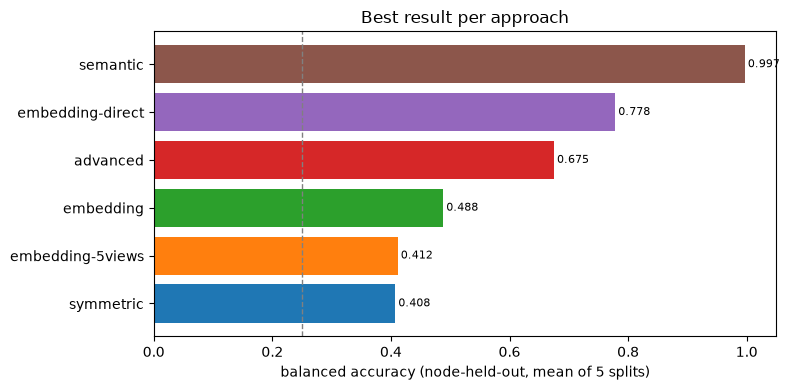

In [21]:
best_by_group = summary_df.groupby('group').head(1).set_index('group')[['combination', 'accuracy', 'balanced_accuracy']]
print("Best result per approach family:")
print(best_by_group.to_string(float_format='%.3f'))

plt.figure(figsize=(8, 4))
order = best_by_group.sort_values('balanced_accuracy')
plt.barh(order.index, order['balanced_accuracy'], color=sns.color_palette('tab10', len(order)))
plt.axvline(0.25, ls='--', color='grey', lw=1)
for k, v in enumerate(order['balanced_accuracy']):
    plt.text(v + 0.005, k, f'{v:.3f}', va='center', fontsize=8)
plt.xlim(0, 1.05); plt.xlabel('balanced accuracy (node-held-out, mean of 5 splits)')
plt.title('Best result per approach'); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'best_per_approach.png'), dpi=100); plt.show()

### Confusion matrices for the key results

For every symmetric method, the check below confirms that the `stronger`
row equals the `weaker` row.

In [22]:
def show_confusion(result):
    cm = result['confusion_matrix']
    cm_pct = cm / (cm.sum(axis=1, keepdims=True) + 1e-9) * 100
    print(f"\n{'=' * 100}\n{result['label']}")
    print(f"accuracy={result['accuracy']:.3f} ± {result['accuracy_std']:.3f}   "
          f"balanced_accuracy={result['balanced_accuracy']:.3f} ± {result['balanced_accuracy_std']:.3f}   "
          f"(pooled over {result['n_splits']} splits, {cm.sum():,} test predictions)")
    print('=' * 100)
    print(pd.DataFrame(cm, index=NAMES, columns=NAMES))
    print(pd.DataFrame(np.round(cm_pct, 1), index=NAMES, columns=NAMES).to_string())

by_label = {r['label']: r for r in results}
key = [summary_df[summary_df.group == g].iloc[0]['combination']
       for g in ['semantic', 'embedding-direct', 'advanced', 'embedding', 'embedding-5views', 'symmetric'] if (summary_df.group == g).any()]
key.insert(1, "SEMANTIC rule: magma counter-models, NO training")
for label in dict.fromkeys(key):
    show_confusion(by_label[label])

print("\n\nDirection-blindness check for EVERY symmetric method:")
for r in results:
    if r.get('group') == 'symmetric' or 'SYMMETRIC' in r['label']:
        cm = r['confusion_matrix']
        print(f"  {'IDENTICAL' if np.array_equal(cm[1], cm[2]) else 'DIFFERENT'}  stronger row {cm[1].tolist()} vs weaker row {cm[2].tolist()}   {r['label']}")


SEMANTIC rule: magma counter-models, NO training
accuracy=0.996 ± 0.004   balanced_accuracy=0.997 ± 0.002   (pooled over 5 splits, 6,786 test predictions)
              equivalent  stronger  weaker  incomparable
equivalent           680         0       0             0
stronger               2      1727       0             0
weaker                 2         0    1727             0
incomparable           0        13      13          2622
              equivalent  stronger  weaker  incomparable
equivalent         100.0       0.0     0.0           0.0
stronger             0.1      99.9     0.0           0.0
weaker               0.1       0.0    99.9           0.0
incomparable         0.0       0.5     0.5          99.0

Generic, RESAMPLED | 19 views | direct latents [A,B,A-B] | HGB
accuracy=0.802 ± 0.034   balanced_accuracy=0.778 ± 0.039   (pooled over 5 splits, 6,786 test predictions)
              equivalent  stronger  weaker  incomparable
equivalent           455       104      95     

## 16. Conclusions, and the recommended setup

The numbers are printed by the cell below, so the conclusions always match
the run.

In [23]:
def best(pred):
    rows = summary_df[summary_df.apply(pred, axis=1)]
    return rows.iloc[0]

b5 = best(lambda r: r.group == 'embedding-5views')
b19 = best(lambda r: r.group == 'embedding')
bsym = best(lambda r: r.group == 'symmetric')
brule = summary_df[summary_df.combination.str.startswith('SEMANTIC rule')].iloc[0]
bsem = best(lambda r: r.group == 'semantic' and not r.combination.startswith('SEMANTIC rule'))
bdir = best(lambda r: r.group == 'embedding-direct')

print(f"Symmetric baselines (best)          : bal acc {bsym.balanced_accuracy:.3f}  -- stronger/weaker rows identical, as proven")
print(f"Embeddings, original 5 views (best) : bal acc {b5.balanced_accuracy:.3f}  ({b5.combination})")
print(f"Embeddings, all 19 views (best)     : bal acc {b19.balanced_accuracy:.3f}  ({b19.combination})")
print(f"Embeddings, direct latents (best)   : bal acc {bdir.balanced_accuracy:.3f}  ({bdir.combination})")
print(f"Semantic rule, zero training        : bal acc {brule.balanced_accuracy:.3f}  acc {brule.accuracy:.3f}")
print(f"Semantic, best learned              : bal acc {bsem.balanced_accuracy:.3f}  acc {bsem.accuracy:.3f}  ({bsem.combination})")
if RUN_FULL_SCALE_SEMANTIC:
    print(f"Semantic rule on ALL {full_scale['pairs']:,} resolvable ETP pairs: "
          f"acc {full_scale['accuracy']:.4f}, bal acc {full_scale['balanced_accuracy']:.4f}")
print("\nFamily ablation (Section 10):")
print(family_df.to_string(index=False, float_format='%.3f'))
print("\nTop 5 single views:")
print(view_df.head(5)[['view', 'family', 'balanced_accuracy']].to_string(index=False, float_format='%.3f'))

Symmetric baselines (best)          : bal acc 0.408  -- stronger/weaker rows identical, as proven
Embeddings, original 5 views (best) : bal acc 0.412  (Family-specific, RESAMPLED | 5 original views | Mix(KL+CE+Rank+LLR))
Embeddings, all 19 views (best)     : bal acc 0.488  (Generic, RAW | 19 views | Mix | HGB + swap-consistency)
Embeddings, direct latents (best)   : bal acc 0.778  (Generic, RESAMPLED | 19 views | direct latents [A,B,A-B] | HGB)
Semantic rule, zero training        : bal acc 0.997  acc 0.996
Semantic, best learned              : bal acc 0.997  acc 0.995  (SEMANTIC learned | semantic + structural + 19-view embedding Mix | HGB + swap-consistency)
Semantic rule on ALL 11,014,285 resolvable ETP pairs: acc 0.9942, bal acc 0.9956

Family ablation (Section 10):
    family  n_views  only_this_family_bal_acc  all_but_this_family_bal_acc
   natural        4                     0.422                        0.448
structural        6                     0.415                        0

### What the results say

1. **Using all 19 representations clearly helps the embedding pipeline.**
   With the original Random Forest, Mix balanced accuracy goes from about
   0.40 (5 views) to about 0.47 (19 views), and direct latents go from 0.69
   to 0.73 (Sections 9 and 12B). No single family dominates. The `natural`
   and `structural` families are the strongest alone (about 0.42 each), and
   they are the only ones whose removal costs more than a point (Section 10).
   The formal family adds little on top of the others: its views share
   near-identical surface syntax.
2. **The loss scalars were the real bottleneck of the embedding approach.**
   Feeding the per-view latents themselves, [z(A), z(B), z(A) − z(B)], to
   gradient boosting (Section 12B) lifts balanced accuracy from about 0.47
   to about 0.78, from the same embeddings.
3. **Symmetric measures stay provably direction-blind** at 19 views: the
   `stronger` and `weaker` rows are identical for every one of them.
4. **The largest gain comes from measuring meaning, not text.** Implication
   between magma laws is a statement about *models*. Checking each equation
   against a bank of about 25k finite magmas (the executable meaning that
   `py_cayley_table` encodes) gives a sound refutation procedure. With **no
   training**, it recovers about 99.5% of the partial order on the held-out
   splits and on all ~11M ETP pairs. Learned models on top match the rule
   but do not beat it, because the rule's residual errors are exactly the
   pairs where no feature available here carries the answer.
5. **The rule's remaining errors are all one-sided.** Each is a false
   implication that no magma in the bank refutes, so the rule predicts a
   relation that is too strong. It never refutes a true implication.

### Recommended setup, in order of expected gain

1. **Semantic backbone (in this notebook):** magma fingerprints over
   structured families (affine, translation-invariant, exhaustive size ≤ 3)
   + the counter-model rule. It is sound, needs no training, and reaches
   about 99%.
2. **Grow the bank where the residual errors are.** Add the magma families
   the ETP used for its hardest refutations: linear magmas over
   non-commutative rings and matrix rings, larger translation-invariant
   magmas via symbolic evaluation, and exhaustive size-4 magmas restricted
   to the equations still unresolved. Every added family can only turn
   "not refuted" into "refuted", so accuracy cannot go down.
3. **Positive certificates for the "holds" side.** Run a first-order prover
   (Vampire, E or Prover9, fed the `tptp`/`smtlib` views that already
   exist) with a short timeout on the pairs the bank does not refute. A
   proof turns a guess into a certificate. The pairs still unresolved are
   exactly where a learned model should decide.
4. **Transitive closure / consistency.** The implication relation is a
   preorder. Project the predicted relation onto a consistent preorder:
   A ⇒ B and B ⇒ C imply A ⇒ C, and a refuted A ⇒ C with a proven A ⇒ B
   refutes B ⇒ C. This propagates refutations to pairs the bank missed
   directly.
5. **Learned model only for the residual.** Use gradient boosting on
   [semantic + structural + 19-view embedding] features with
   swap-consistency (Section 13b), trained only on pairs the bank leaves
   open. This is where the 19 text representations are genuinely useful:
   as tie-breakers, not as the primary signal.
6. **If a neural model is wanted:** a contrastive, *order* embedding (for
   example box or order embeddings, with A ⇒ B ⇔ box(A) ⊆ box(B)) trained
   on the magma fingerprints plus one text view. This is asymmetric by
   construction, unlike cosine, and it generalises to equations outside
   the catalogue.